# Relative abundance: final steady state vs. initial homogeneous state

Loads the per-run state pkls written by
`scripts/20260723_task3_single_influx_pde_sweep.py` and, for every strain,
compares its **integrated relative abundance** in the final spatial steady
state against its relative abundance in the initial homogeneous fixed point.

- **Initial (homogeneous):** biomass is uniform, so strain $i$'s integrated
  biomass is $u^{ss}_i \cdot L$; the box length $L$ cancels in the relative
  abundance, which is therefore just the composition of the well-mixed
  fixed point $u^{ss}_i / \sum_j u^{ss}_j$ (stored per run as `u_ss`).
- **Final:** integrate each strain's field over space,
  $B_i = \int N_i(x)\,dx \approx (\sum_x N_i)\,\Delta x$, then normalise.

One scatter panel per byproduct-diffusion value $p \equiv D_\mathrm{byprod}$
(with $D_\mathrm{influx}=1$, so $p$ is the byprod/influx diffusion ratio),
on log-log axes with the identity line $y=x$.

In [1]:
import sys, pathlib, glob, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import palettable as pal

_root = pathlib.Path.cwd().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": '.9', 'grid.linestyle': '--',
                            'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

colorTable = {}
colorTable['k'] = [0, 0, 0]
colorTable['g'] = [27/255, 158/255, 119/255]
colorTable['o'] = [217/255, 95/255, 2/255]

In [2]:
# --- load every per-run state pkl -----------------------------------------
STATE_DIR = _root / 'scripts' / '20260723_task3_output' / 'states'
files = sorted(STATE_DIR.glob('*.pkl'))
print(f'{len(files)} per-run state files in {STATE_DIR}')

EPS = 1e-6  # relative-abundance cutoff for a strain to count as 'present'

records = []  # one entry per run: D_byprod + per-strain init/final rel. abundance
for f in files:
    d = pickle.load(open(f, 'rb'))
    if not d.get('success', False):
        continue
    Ns, dx = d['Ns'], d['dx']
    init_bio = np.clip(d['u_ss'][:Ns], 0.0, None)              # homogeneous strain biomass
    final_bio = np.clip(d['strains'].sum(axis=1) * dx, 0.0, None)  # integrated over space
    init_rel = init_bio / init_bio.sum() if init_bio.sum() > 0 else init_bio
    final_rel = final_bio / final_bio.sum() if final_bio.sum() > 0 else final_bio
    L = d['ssize'] * dx                              # box length
    records.append(dict(D=float(d['D_byprod']), init_rel=init_rel, final_rel=final_rel,
                        init_tot=init_bio.sum() * L,   # integrated homogeneous biomass
                        final_tot=final_bio.sum()))    # integrated final biomass

Dvals = sorted({r['D'] for r in records})
print(f'{len(records)} successful runs;  {len(Dvals)} D_byprod values:',
      [f'{D:.4g}' for D in Dvals])

999 per-run state files in /media/kabir/8331fe27-69c5-463e-a8db-719f7dc905ef/home/kabir/Work/UCL/Projects/2025 Spatial Ecology/20260410 Jans Code/SSMC-python/scripts/20260723_task3_output/states
999 successful runs;  10 D_byprod values: ['0.001', '0.002154', '0.004642', '0.01', '0.02154', '0.04642', '0.1', '0.2154', '0.4642', '1']


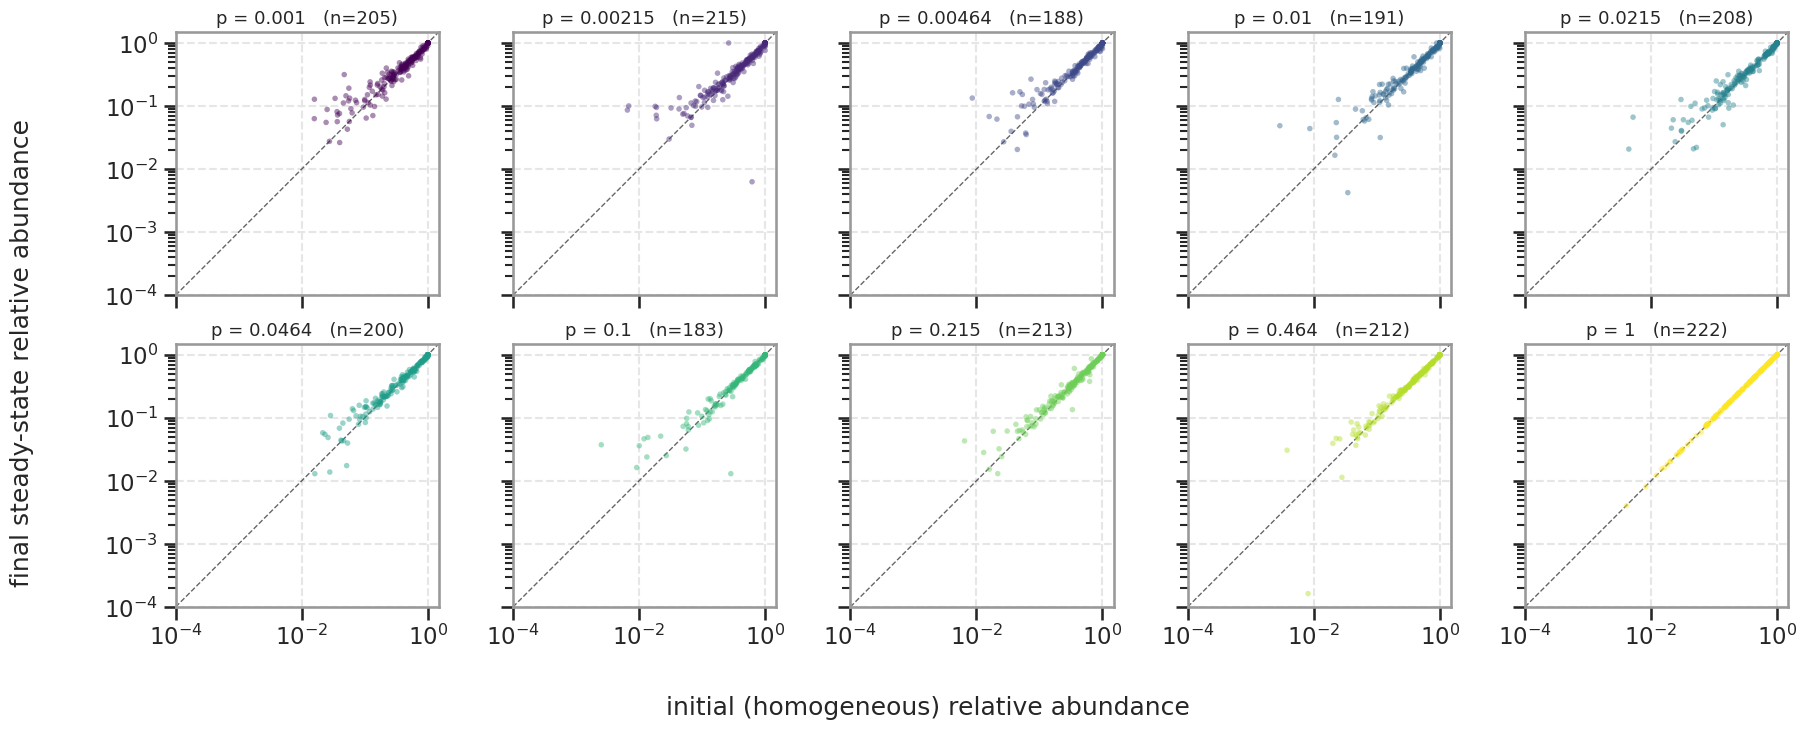

In [3]:
# --- one log-log scatter panel per p = D_byprod ----------------------------
ncol = 5
nrow = int(np.ceil(len(Dvals) / ncol))
colors = plt.cm.viridis(np.linspace(0, 1, len(Dvals)))
lim = [1e-4, 1.5]

fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.6 * nrow),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ai, (D, ax) in enumerate(zip(Dvals, axes)):
    xs, ys = [], []
    for r in records:
        if r['D'] != D:
            continue
        m = (r['init_rel'] > EPS) & (r['final_rel'] > EPS)
        xs.append(r['init_rel'][m]); ys.append(r['final_rel'][m])
    xs = np.concatenate(xs) if xs else np.array([])
    ys = np.concatenate(ys) if ys else np.array([])
    ax.plot(lim, lim, '--', color=colorTable['k'], lw=1, alpha=0.6, zorder=1)
    ax.scatter(xs, ys, s=16, color=colors[ai], alpha=0.45, edgecolor='none', zorder=2)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.set_title(f'p = {D:.3g}   (n={xs.size})', fontsize=13)

for ax in axes[len(Dvals):]:
    ax.axis('off')

fig.supxlabel('initial (homogeneous) relative abundance', y=-0.01)
fig.supylabel('final steady-state relative abundance', x=-0.01)
fig.tight_layout()

OUT = _root / 'scripts' / '20260723_task3_output'
fig.savefig(OUT / '20260724_relabund_init_vs_final.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT / '20260724_relabund_init_vs_final.svg', bbox_inches='tight')
plt.show()

Points on the dashed identity line mean the strain keeps the same share of
total biomass after pattern formation; departures show how the spatial
instability redistributes biomass among the surviving strains. Strains that
are extinct at the homogeneous fixed point stay extinct and fall below the
`EPS` cutoff, so they are omitted from the log-log axes.

## Distribution of the abundance ratio (final / initial)

For each surviving strain, the ratio of its final integrated relative
abundance to its initial homogeneous relative abundance. A ratio of 1
(dashed line) means the strain kept its share of total biomass. If pattern
formation leaves the composition unchanged as $p\to1$, these histograms
should concentrate on 1 (log-width $\to0$); the annotated
$\sigma_{\log_{10}}$ is the spread of $\log_{10}(\text{ratio})$.

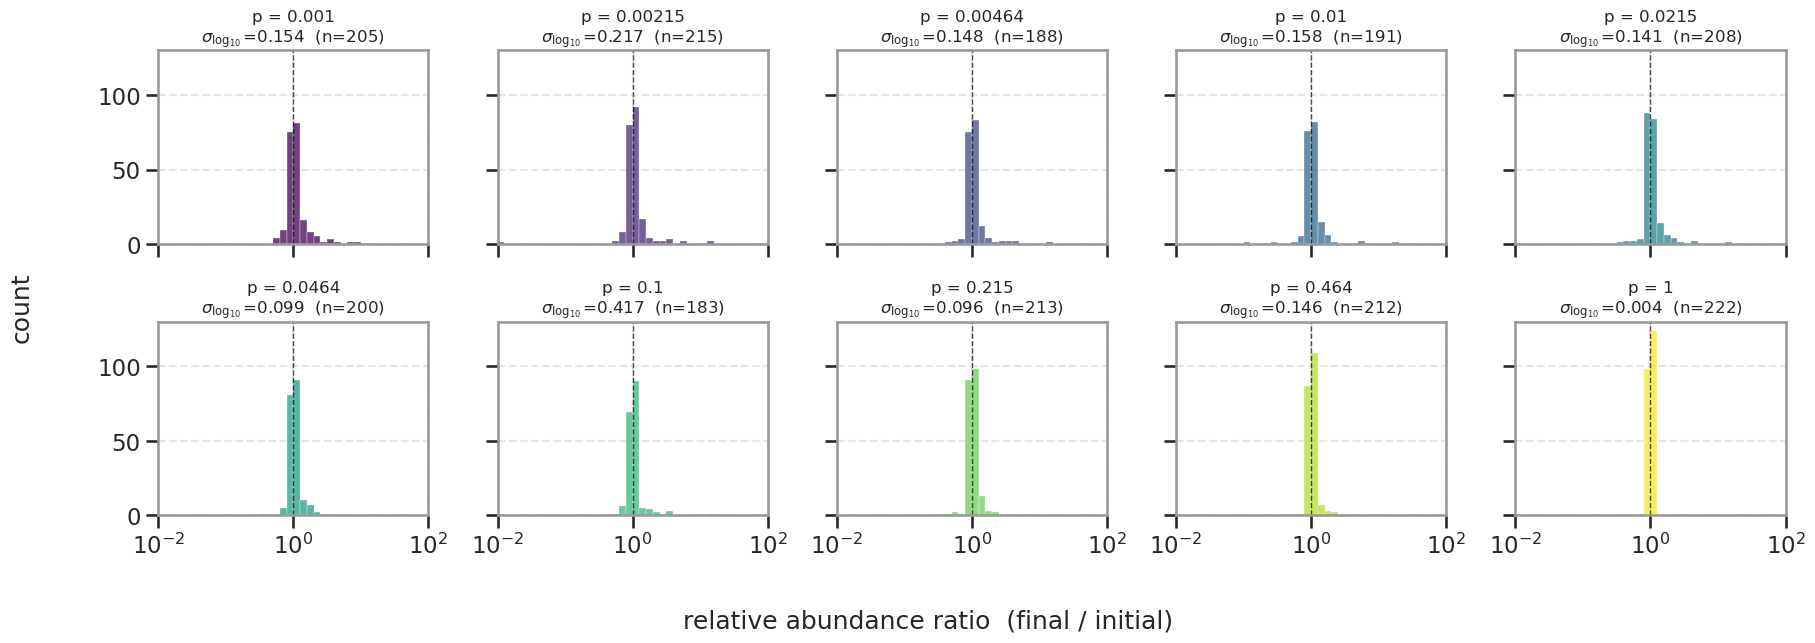

In [4]:
# --- histogram of final/initial relative-abundance ratio, per p ------------
bins = np.logspace(-2, 2, 41)          # fixed log range so panels compare
rlim = [bins[0], bins[-1]]

fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.2 * nrow),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ai, (D, ax) in enumerate(zip(Dvals, axes)):
    ratios = []
    for r in records:
        if r['D'] != D:
            continue
        m = (r['init_rel'] > EPS) & (r['final_rel'] > EPS)
        ratios.append(r['final_rel'][m] / r['init_rel'][m])
    ratios = np.concatenate(ratios) if ratios else np.array([])
    sigma = np.std(np.log10(ratios)) if ratios.size else np.nan
    ax.hist(np.clip(ratios, rlim[0], rlim[1]), bins=bins,
            color=colors[ai], alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(1.0, ls='--', color=colorTable['k'], lw=1, alpha=0.7)
    ax.set_xscale('log')
    ax.set_xlim(rlim)
    ax.set_title(f'p = {D:.3g}\n$\\sigma_{{\\log_{{10}}}}$={sigma:.3f}  (n={ratios.size})',
                 fontsize=12)

for ax in axes[len(Dvals):]:
    ax.axis('off')

fig.supxlabel('relative abundance ratio  (final / initial)', y=-0.01)
fig.supylabel('count', x=-0.01)
fig.tight_layout()
fig.savefig(OUT / '20260724_relabund_ratio_hist.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT / '20260724_relabund_ratio_hist.svg', bbox_inches='tight')
plt.show()

## Total integrated biomass (summed over all strains)

One point **per community**: the total biomass integrated over space,
$B_\mathrm{tot}=\sum_i\int N_i(x)\,dx$, in the final steady state vs. the
homogeneous initial state ($\sum_i u^{ss}_i\,L$). This asks whether pattern
formation changes the *amount* of biomass a community supports, and whether
that depends on $p=D_\mathrm{byprod}$.

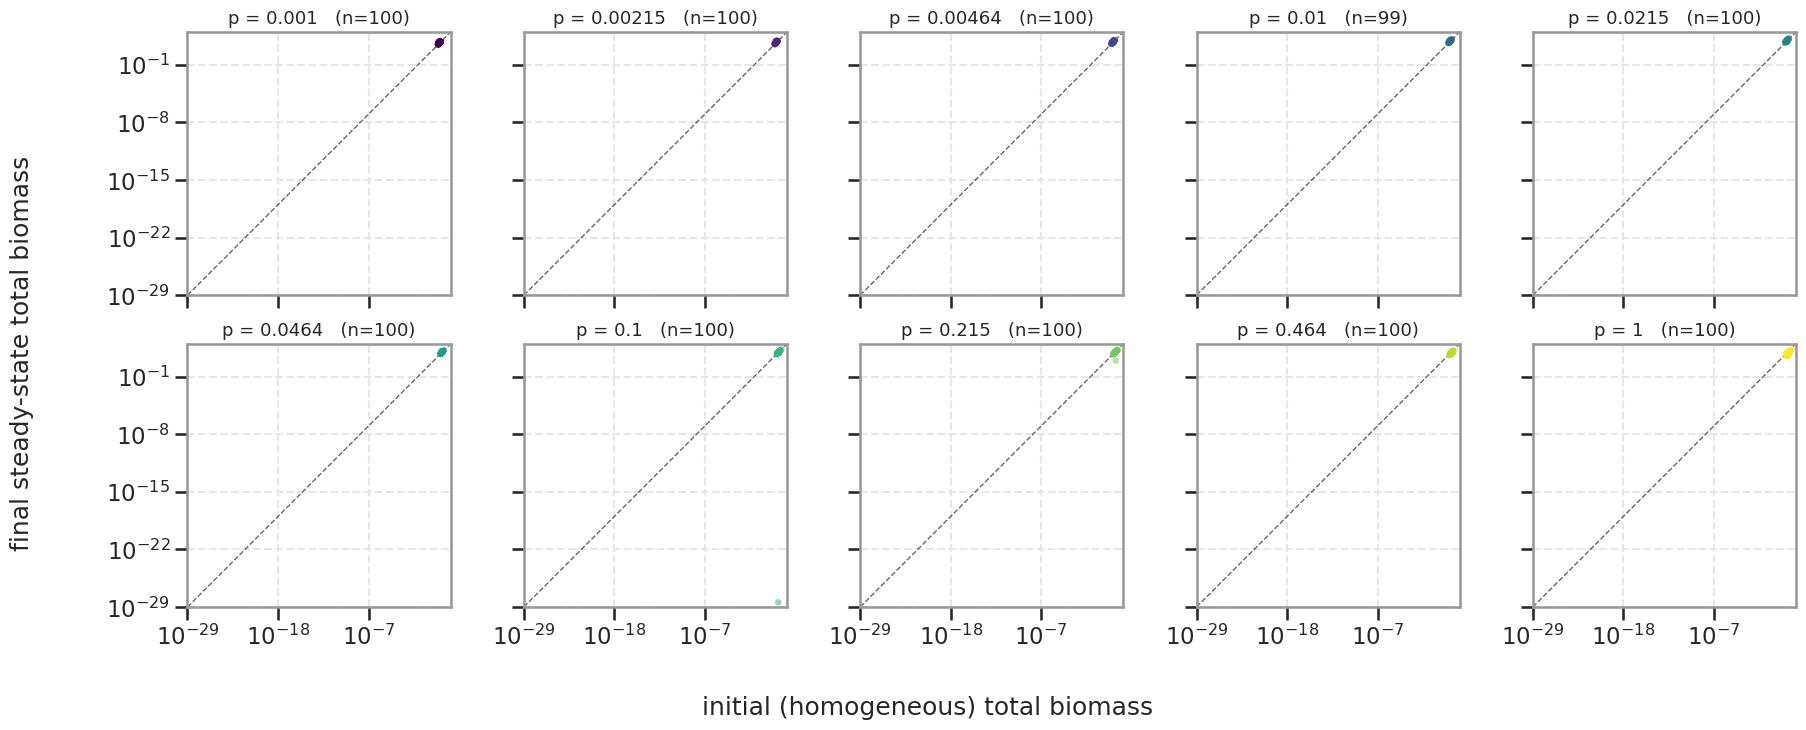

In [5]:
# --- final vs initial total integrated biomass (per community), per p ------
it = np.array([r['init_tot'] for r in records])
ft = np.array([r['final_tot'] for r in records])
tlim = [10 ** np.floor(np.log10(min(it.min(), ft.min()))),
        10 ** np.ceil(np.log10(max(it.max(), ft.max())))]

fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.6 * nrow),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ai, (D, ax) in enumerate(zip(Dvals, axes)):
    x = np.array([r['init_tot'] for r in records if r['D'] == D])
    y = np.array([r['final_tot'] for r in records if r['D'] == D])
    ax.plot(tlim, tlim, '--', color=colorTable['k'], lw=1, alpha=0.6, zorder=1)
    ax.scatter(x, y, s=22, color=colors[ai], alpha=0.55, edgecolor='none', zorder=2)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(tlim); ax.set_ylim(tlim)
    ax.set_aspect('equal')
    ax.set_title(f'p = {D:.3g}   (n={x.size})', fontsize=13)
for ax in axes[len(Dvals):]:
    ax.axis('off')
fig.supxlabel('initial (homogeneous) total biomass', y=-0.01)
fig.supylabel('final steady-state total biomass', x=-0.01)
fig.tight_layout()
fig.savefig(OUT / '20260724_totbiomass_init_vs_final.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT / '20260724_totbiomass_init_vs_final.svg', bbox_inches='tight')
plt.show()

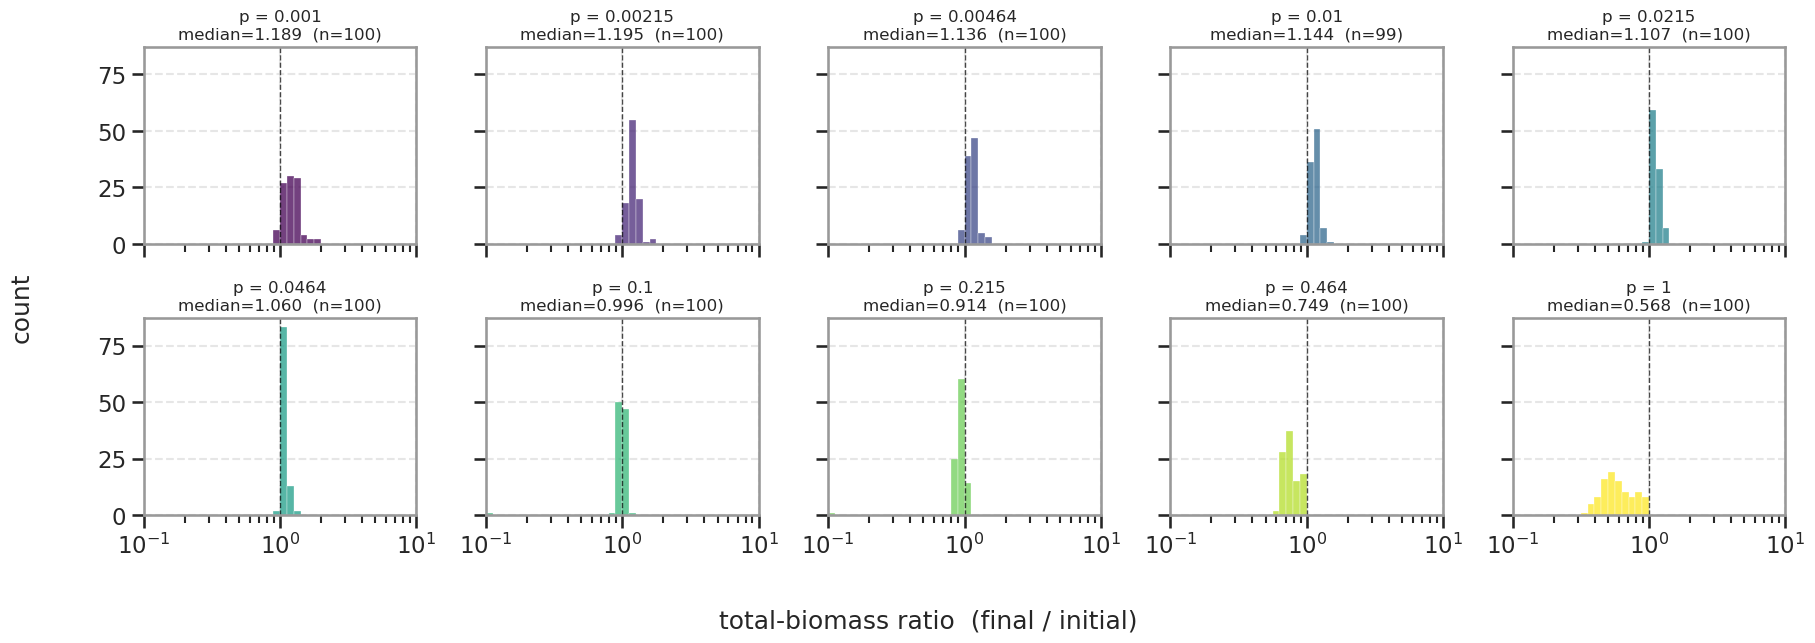

median (final/initial) total biomass by p:
  p=0.001     median ratio = 1.1889
  p=0.002154  median ratio = 1.1948
  p=0.004642  median ratio = 1.1361
  p=0.01      median ratio = 1.1444
  p=0.02154   median ratio = 1.1066
  p=0.04642   median ratio = 1.0603
  p=0.1       median ratio = 0.9964
  p=0.2154    median ratio = 0.9137
  p=0.4642    median ratio = 0.7495
  p=1         median ratio = 0.5678


In [6]:
# --- histogram of total-biomass ratio (final / initial), per p -------------
tbins = np.logspace(-1, 1, 41)
trlim = [tbins[0], tbins[-1]]
med_by_p = []
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.2 * nrow),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ai, (D, ax) in enumerate(zip(Dvals, axes)):
    ratio = np.array([r['final_tot'] / r['init_tot'] for r in records
                      if r['D'] == D and r['init_tot'] > 0])
    med = np.median(ratio) if ratio.size else np.nan
    med_by_p.append((D, med))
    ax.hist(np.clip(ratio, trlim[0], trlim[1]), bins=tbins,
            color=colors[ai], alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(1.0, ls='--', color=colorTable['k'], lw=1, alpha=0.7)
    ax.set_xscale('log'); ax.set_xlim(trlim)
    ax.set_title(f'p = {D:.3g}\nmedian={med:.3f}  (n={ratio.size})', fontsize=12)
for ax in axes[len(Dvals):]:
    ax.axis('off')
fig.supxlabel('total-biomass ratio  (final / initial)', y=-0.01)
fig.supylabel('count', x=-0.01)
fig.tight_layout()
fig.savefig(OUT / '20260724_totbiomass_ratio_hist.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT / '20260724_totbiomass_ratio_hist.svg', bbox_inches='tight')
plt.show()

print('median (final/initial) total biomass by p:')
for D, med in med_by_p:
    print(f'  p={D:<8.4g}  median ratio = {med:.4f}')